# =====================================================
# PROYECTO FINAL
# ANÁLISIS EXPLORATORIO Y CONTRASTE DE HIPÓTESIS SOBRE RENDIMIENTO ACADÉMICO
# =====================================================

# Sección II. Análisis Exploratorio de Datos

En continuidad con la fase de ingeniería de datos, este notebook desarrolla un **Análisis Exploratorio de Datos (EDA)**
sobre el conjunto `student-mat.csv`, integrado por 395 estudiantes de Matemáticas y 33 variables de naturaleza
académica, personal, familiar y social.

El propósito analítico consiste en describir la estructura del conjunto, identificar patrones relevantes y evaluar
relaciones preliminares entre variables explicativas y rendimiento académico.

Las preguntas de investigación que guían esta fase son:

1. ¿Los estudiantes con acceso a internet presentan mejores calificaciones que aquellos sin acceso?
2. ¿Existen diferencias en el rendimiento académico entre estudiantes de zonas urbanas y rurales?
3. ¿Cómo se relaciona el nivel educativo de la madre y del padre con la nota final?
4. ¿El apoyo educativo familiar se relaciona con una mayor probabilidad de aprobación?
5. ¿La calidad de las relaciones familiares influye en el desempeño académico?
6. ¿Cuáles factores familiares y digitales tienen mayor importancia en los modelos predictivos?
7. ¿Es posible identificar estudiantes en riesgo utilizando solamente variables familiares, personales y digitales?

Los entregables principales incluyen estadísticos descriptivos, visualizaciones univariadas y bivariadas, análisis de
correlación e interpretación de hallazgos con soporte gráfico.

# 1. Preparación del entorno y carga del conjunto de datos

In [1]:
# Cargar librerías necesarias para el análisis exploratorio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook', palette='Set2')
plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

def find_project_root() -> Path:
    """Return the repository root regardless of the current working directory."""
    cwd = Path.cwd().resolve()
    for anchor in [cwd, *cwd.parents]:
        direct = anchor / "data" / "raw" / "student-mat.csv"
        if direct.exists():
            return anchor
        nested = anchor / "projects" / "final_project_utp" / "data" / "raw" / "student-mat.csv"
        if nested.exists():
            return anchor / "projects" / "final_project_utp"
    raise FileNotFoundError("No se encontró la raíz del proyecto con la carpeta data/raw.")

PROJECT_ROOT = find_project_root()

Para el análisis exploratorio se carga el dataset **original** (`student-mat.csv`), conservando las
etiquetas de texto (`yes/no`, `U/R`, etc.). Esto hace las gráficas agrupadas más legibles.
La versión codificada numéricamente (`student_clean.csv`) que produjo el Ingeniero de Datos se usa
más adelante por el Científico de Datos y el Ingeniero de ML para el entrenamiento de modelos.

In [2]:
# Cargar dataset original (etiquetas legibles para el EDA)
df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [3]:
# Dimensiones y verificación rápida (coincide con lo entregado por el Ingeniero de Datos)
print("Filas y columnas:", df.shape)
print("Valores faltantes totales:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

Filas y columnas: (395, 33)
Valores faltantes totales: 0
Filas duplicadas: 0


### Variable derivada: `aprobado`
La nota final `G3` está en escala **0 a 20**. Siguiendo el criterio estándar de este dataset,
se considera **Aprobado** al estudiante con `G3 >= 10` y **Reprobado** en caso contrario.
Esta variable se usará para responder las preguntas sobre probabilidad de aprobación.

In [4]:
df['aprobado'] = np.where(df['G3'] >= 10, 'Aprobado', 'Reprobado')
print(df['aprobado'].value_counts())
print("\nTasa de aprobación general: {:.1f}%".format((df['aprobado']=='Aprobado').mean()*100))

aprobado
Aprobado     265
Reprobado    130
Name: count, dtype: int64

Tasa de aprobación general: 67.1%


# 2. Medidas de tendencia central

Resumen estadístico de las variables numéricas del dataset.

In [5]:
df.describe().T[['mean','50%','std','min','max']].round(2)

,mean,50%,std,min,max
age,16.70,17.0,1.28,15.0,22.0
Medu,2.75,3.0,1.09,0.0,4.0
Fedu,2.52,2.0,1.09,0.0,4.0
traveltime,1.45,1.0,0.70,1.0,4.0
studytime,2.04,2.0,0.84,1.0,4.0
failures,0.33,0.0,0.74,0.0,3.0
famrel,3.94,4.0,0.90,1.0,5.0
freetime,3.24,3.0,1.00,1.0,5.0
goout,3.11,3.0,1.11,1.0,5.0
Dalc,1.48,1.0,0.89,1.0,5.0


Tabla comparativa de **media, mediana, moda y desviación estándar** para las variables numéricas.
Permite ver rápidamente el centro y la dispersión de cada variable.

In [6]:
num_cols = df.select_dtypes(include=np.number).columns
tendencia = pd.DataFrame({
    'Media':    df[num_cols].mean().round(2),
    'Mediana':  df[num_cols].median(),
    'Moda':     df[num_cols].mode().iloc[0],
    'Desv_Est': df[num_cols].std().round(2),
})
tendencia

,Media,Mediana,Moda,Desv_Est
age,16.70,17.0,16,1.28
Medu,2.75,3.0,4,1.09
Fedu,2.52,2.0,2,1.09
traveltime,1.45,1.0,1,0.70
studytime,2.04,2.0,2,0.84
failures,0.33,0.0,0,0.74
famrel,3.94,4.0,4,0.90
freetime,3.24,3.0,3,1.00
goout,3.11,3.0,3,1.11
Dalc,1.48,1.0,1,0.89


Para las variables **categóricas**, la medida de tendencia central es la **moda** (valor más frecuente).

In [7]:
cat_cols = df.select_dtypes(include='object').columns.drop('aprobado')
for c in cat_cols:
    vc = df[c].value_counts()
    print(f"{c:11s} -> moda: {df[c].mode()[0]:<8}  distribución: {vc.to_dict()}")

school      -> moda: GP        distribución: {'GP': 349, 'MS': 46}
sex         -> moda: F         distribución: {'F': 208, 'M': 187}
address     -> moda: U         distribución: {'U': 307, 'R': 88}
famsize     -> moda: GT3       distribución: {'GT3': 281, 'LE3': 114}
Pstatus     -> moda: T         distribución: {'T': 354, 'A': 41}
Mjob        -> moda: other     distribución: {'other': 141, 'services': 103, 'at_home': 59, 'teacher': 58, 'health': 34}
Fjob        -> moda: other     distribución: {'other': 217, 'services': 111, 'teacher': 29, 'at_home': 20, 'health': 18}
reason      -> moda: course    distribución: {'course': 145, 'home': 109, 'reputation': 105, 'other': 36}
guardian    -> moda: mother    distribución: {'mother': 273, 'father': 90, 'other': 32}
schoolsup   -> moda: no        distribución: {'no': 344, 'yes': 51}
famsup      -> moda: yes       distribución: {'yes': 242, 'no': 153}
paid        -> moda: no        distribución: {'no': 214, 'yes': 181}
activities  -> moda: yes 

/tmp/ipykernel_70513/4041266660.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.drop('aprobado')


# 3. Histogramas

Distribución de las principales variables numéricas mediante histogramas.

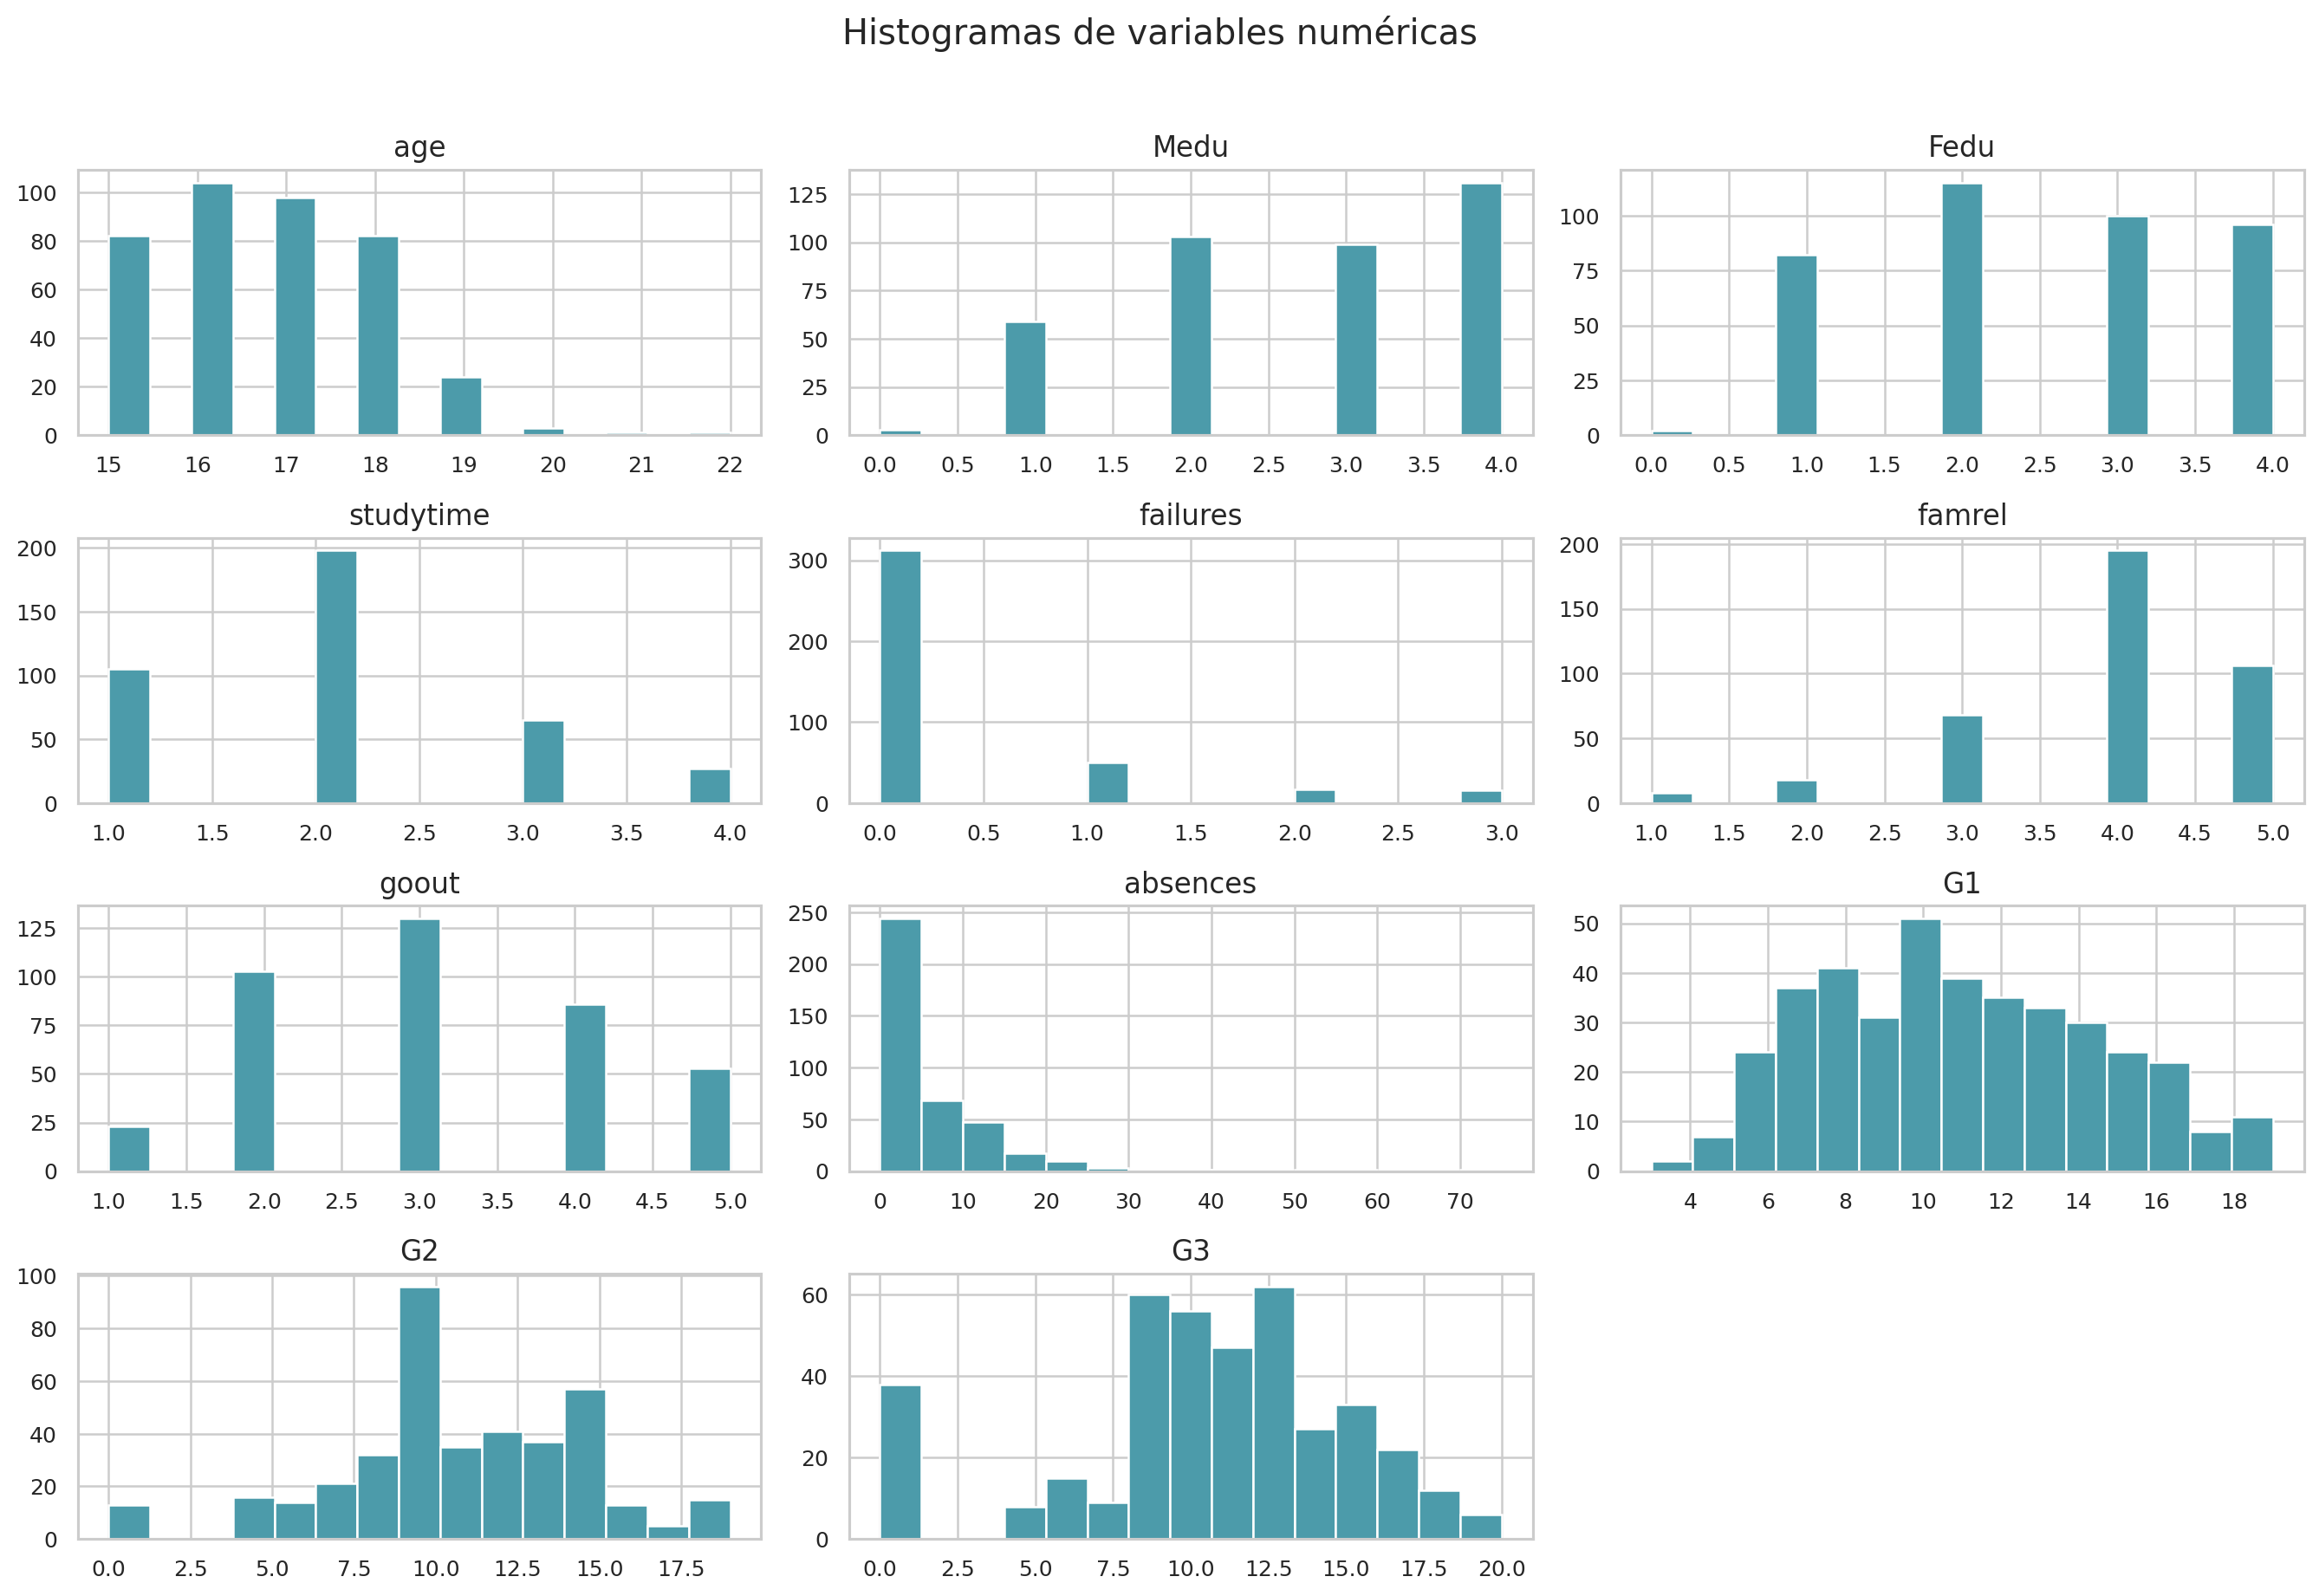

In [8]:
num_plot = ['age','Medu','Fedu','studytime','failures','famrel',
            'goout','absences','G1','G2','G3']
df[num_plot].hist(figsize=(15,10), bins=15, color='#4C9BAA', edgecolor='white')
plt.suptitle("Histogramas de variables numéricas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observaciones:**
- `age` se concentra entre 15 y 18 años.
- `failures` (fracasos previos) está muy sesgada: la mayoría de estudiantes tiene 0.
- Las notas `G1`, `G2` y `G3` tienen forma aproximadamente normal; en `G3` destaca un pico en 0
  (estudiantes que abandonaron o reprobaron con nota 0).

# 4. Boxplots

Los boxplots permiten identificar la dispersión y posibles valores atípicos.

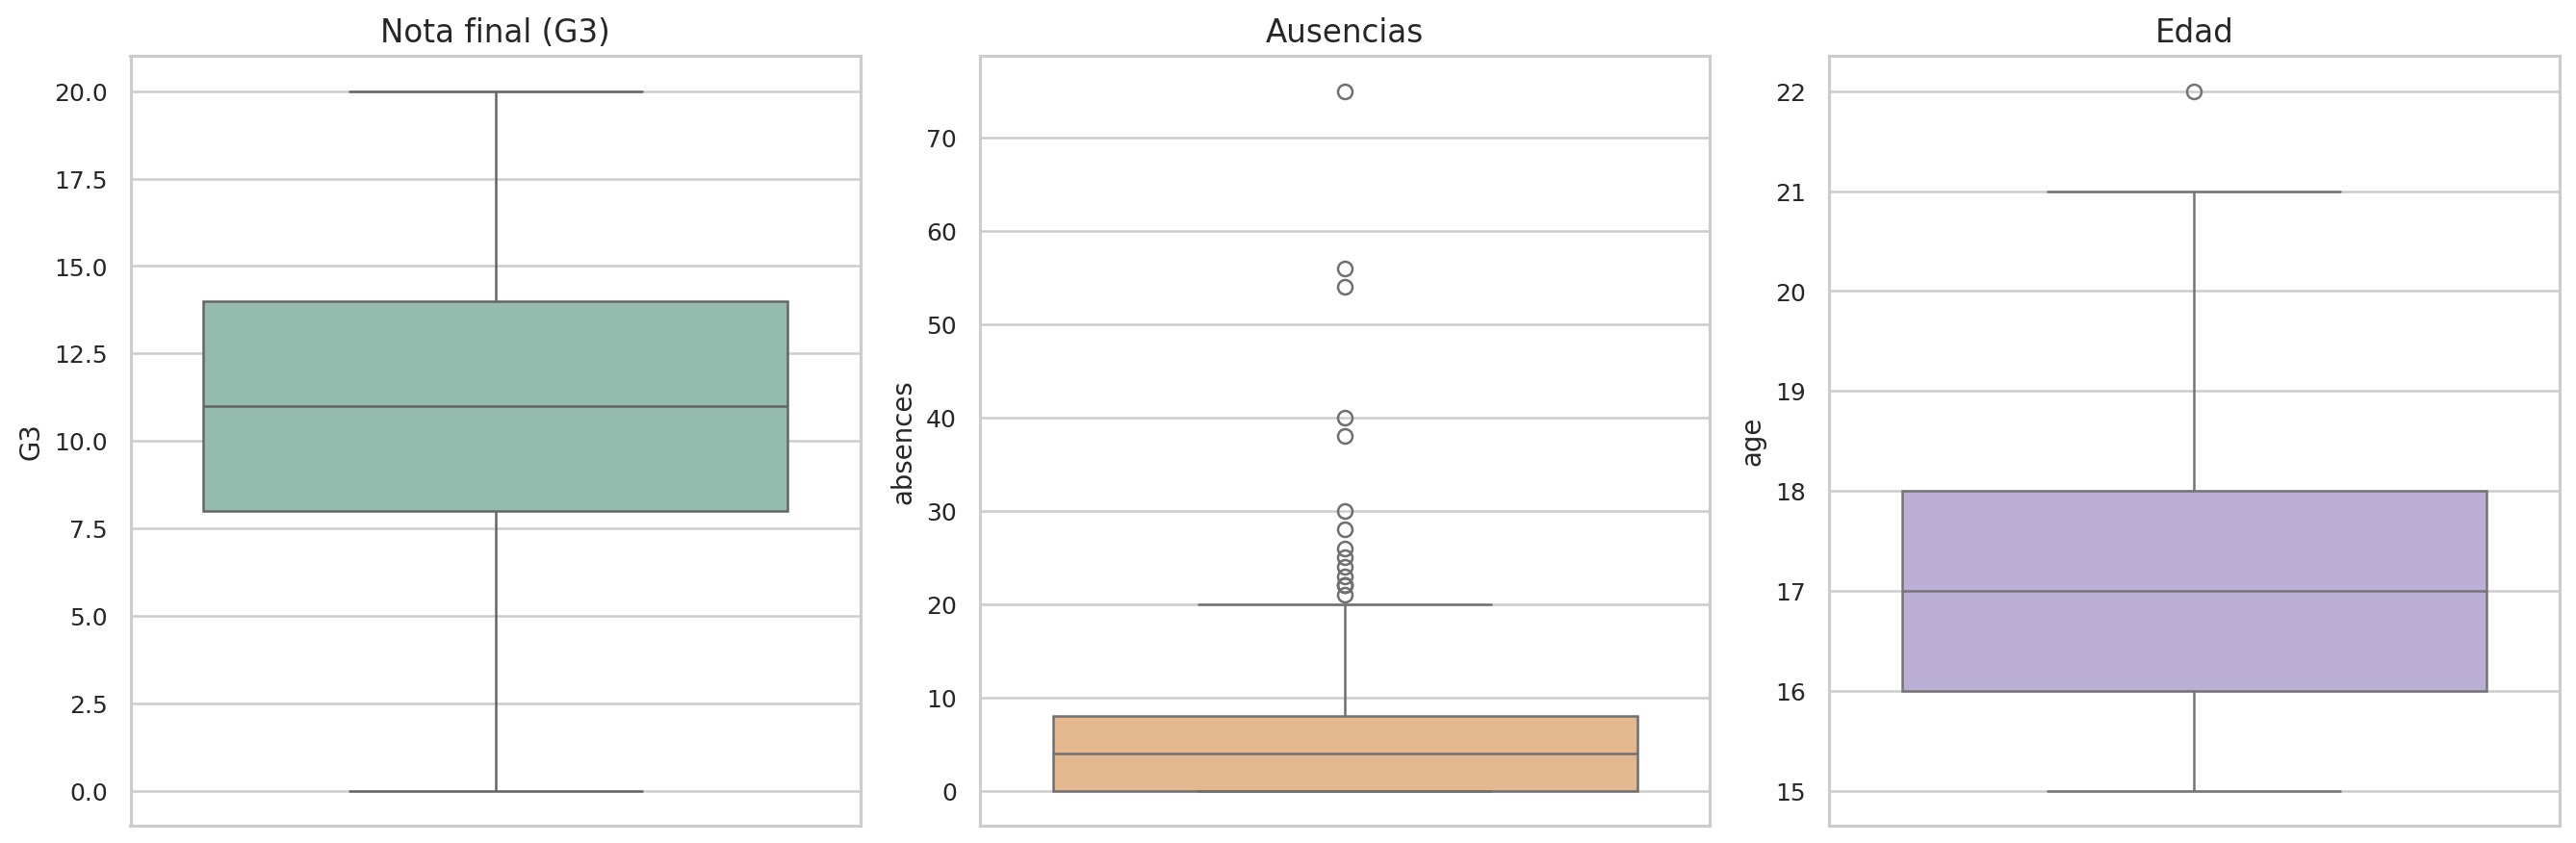

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(y=df['G3'], ax=axes[0], color='#8EC1B0')
axes[0].set_title('Nota final (G3)')
sns.boxplot(y=df['absences'], ax=axes[1], color='#F2B880')
axes[1].set_title('Ausencias')
sns.boxplot(y=df['age'], ax=axes[2], color='#B8A9DB')
axes[2].set_title('Edad')
plt.tight_layout()
plt.show()

La variable `absences` presenta varios valores altos (hasta 75), coherente con lo señalado por el
Ingeniero de Datos: son valores extremos pero **plausibles**, no errores, por lo que se conservan.
`G3` muestra los ceros en la parte inferior como puntos separados.

# 5. Distribuciones

Distribución de las notas con curva de densidad (KDE) y coeficiente de asimetría (*skew*).

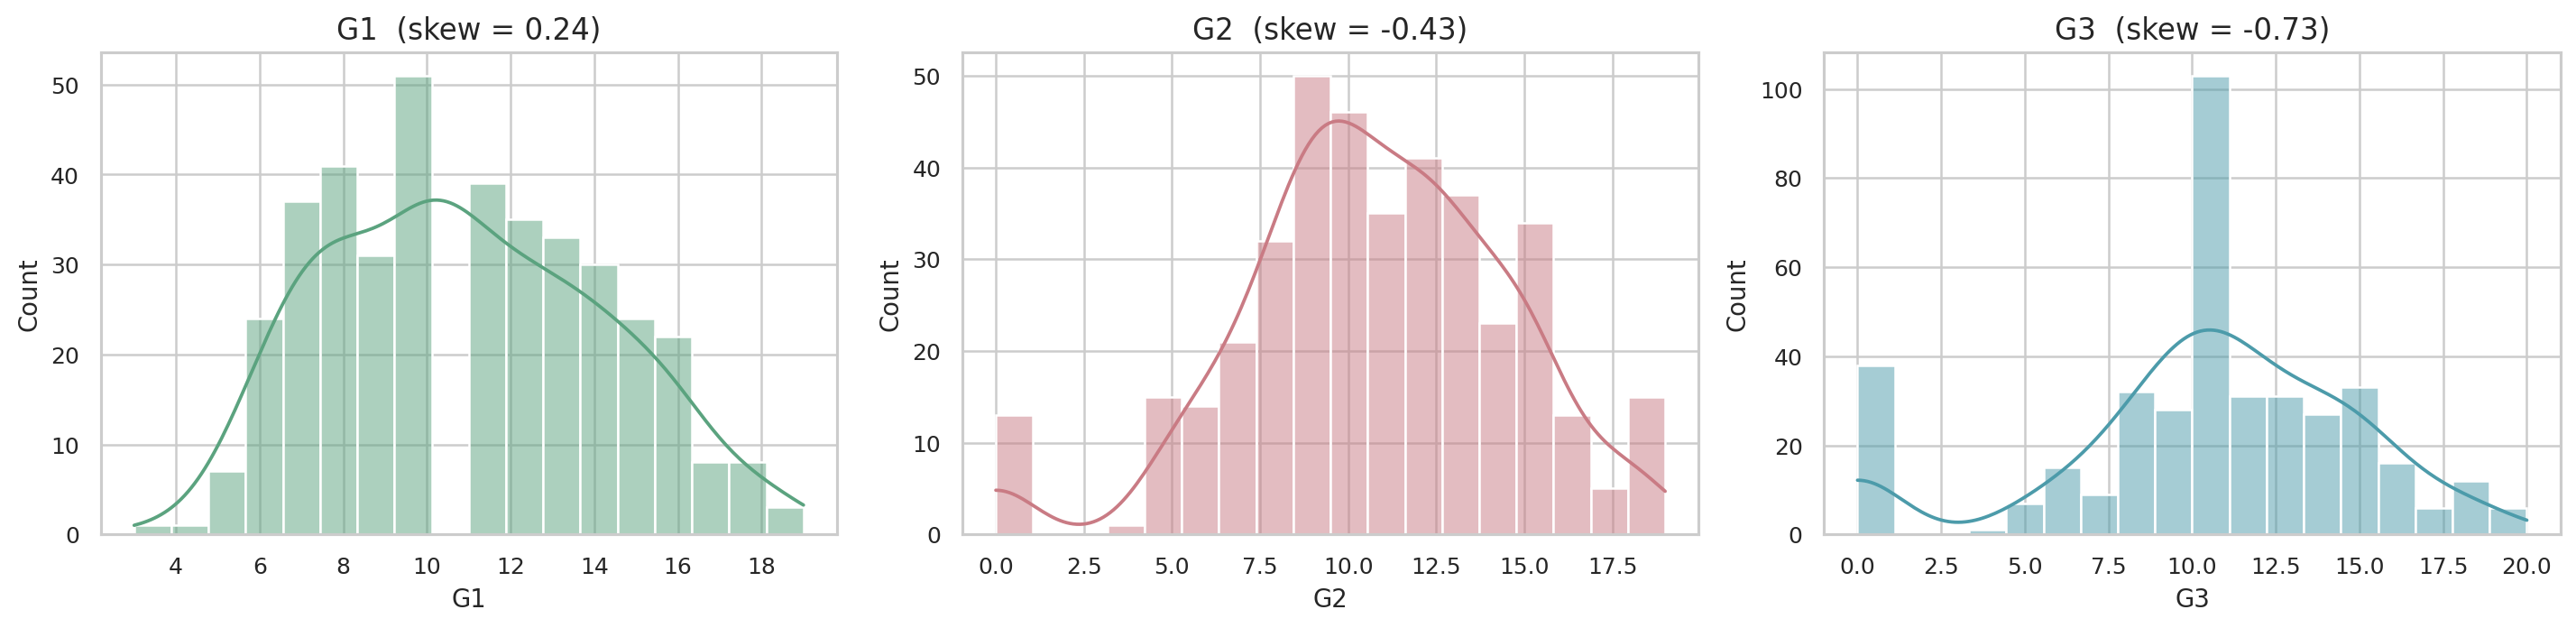

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col, color in zip(axes, ['G1','G2','G3'],
                          ['#5BA37F','#C97B84','#4C9BAA']):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=18)
    ax.set_title(f"{col}  (skew = {df[col].skew():.2f})")
plt.tight_layout()
plt.show()

/tmp/ipykernel_70513/4087965396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='aprobado', palette=['#4C9BAA','#C0504D'])


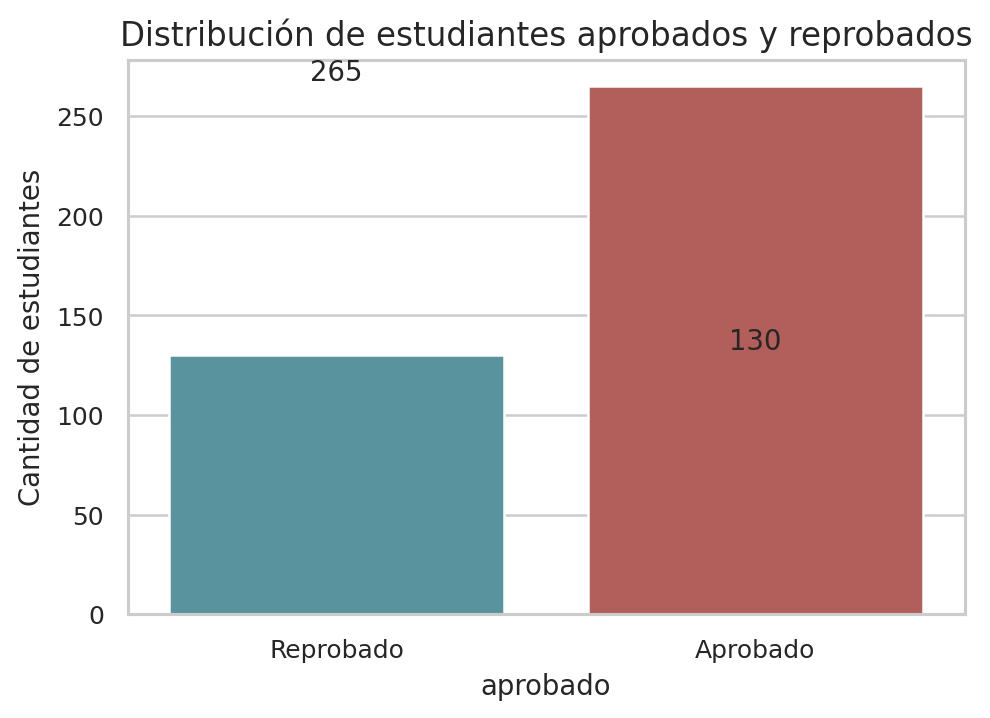

In [11]:
# Distribución de aprobados vs reprobados
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='aprobado', palette=['#4C9BAA','#C0504D'])
plt.title('Distribución de estudiantes aprobados y reprobados')
plt.ylabel('Cantidad de estudiantes')
for i, v in enumerate(df['aprobado'].value_counts()[['Aprobado','Reprobado']]):
    plt.text(i, v+3, str(v), ha='center')
plt.show()

# 6. Gráficas agrupadas

En esta sección se responden las preguntas de investigación mediante gráficas agrupadas por
categorías.

### Pregunta 1 — Acceso a internet y calificaciones
*¿Los estudiantes con acceso a internet presentan mejores calificaciones?*

/tmp/ipykernel_70513/904175423.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='internet', y='G3', ax=axes[0], palette='Set2')
/tmp/ipykernel_70513/904175423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')


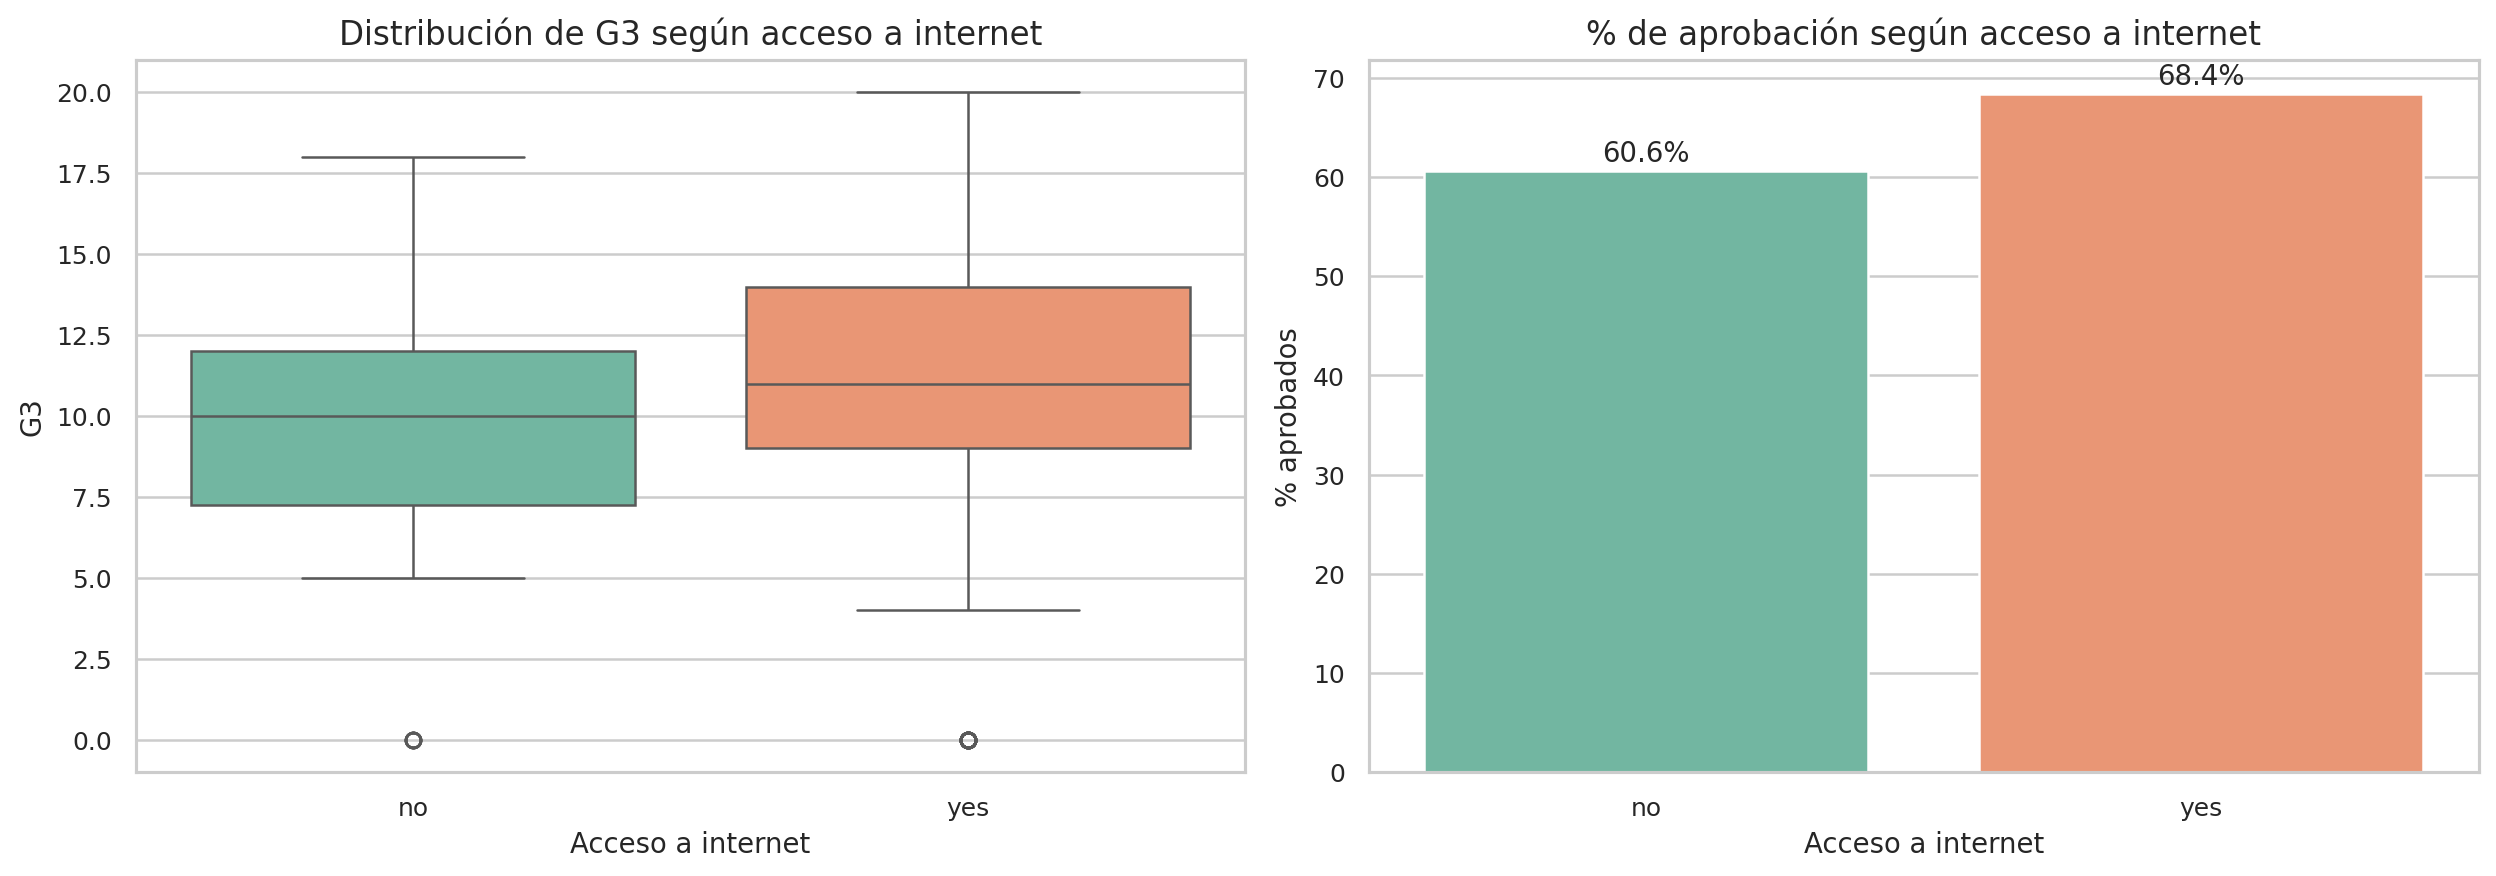

           mean  median  count
internet                      
no         9.41    10.0     66
yes       10.62    11.0    329


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='internet', y='G3', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de G3 según acceso a internet')
axes[0].set_xlabel('Acceso a internet')

tasa = df.groupby('internet')['aprobado'].apply(lambda s:(s=='Aprobado').mean()*100)
sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')
axes[1].set_title('% de aprobación según acceso a internet')
axes[1].set_ylabel('% aprobados'); axes[1].set_xlabel('Acceso a internet')
for i, v in enumerate(tasa.values):
    axes[1].text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout(); plt.show()

print(df.groupby('internet')['G3'].agg(['mean','median','count']).round(2))

**Hallazgo:** los estudiantes **con** internet obtienen en promedio **10.62** en G3 frente a **9.41**
de los que no tienen (≈1.2 puntos más), y su tasa de aprobación es mayor (**68.4%** vs **60.6%**).
La diferencia existe pero es **moderada**: internet ayuda, aunque no es un factor determinante por sí
solo. *(Nota: solo 66 de 395 estudiantes no tienen internet.)*

### Pregunta 2 — Zona urbana vs rural
*¿Existen diferencias entre estudiantes de zonas urbanas (U) y rurales (R)?*

/tmp/ipykernel_70513/3421954384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='zona', y='G3', ax=axes[0], palette='Set2')
/tmp/ipykernel_70513/3421954384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')


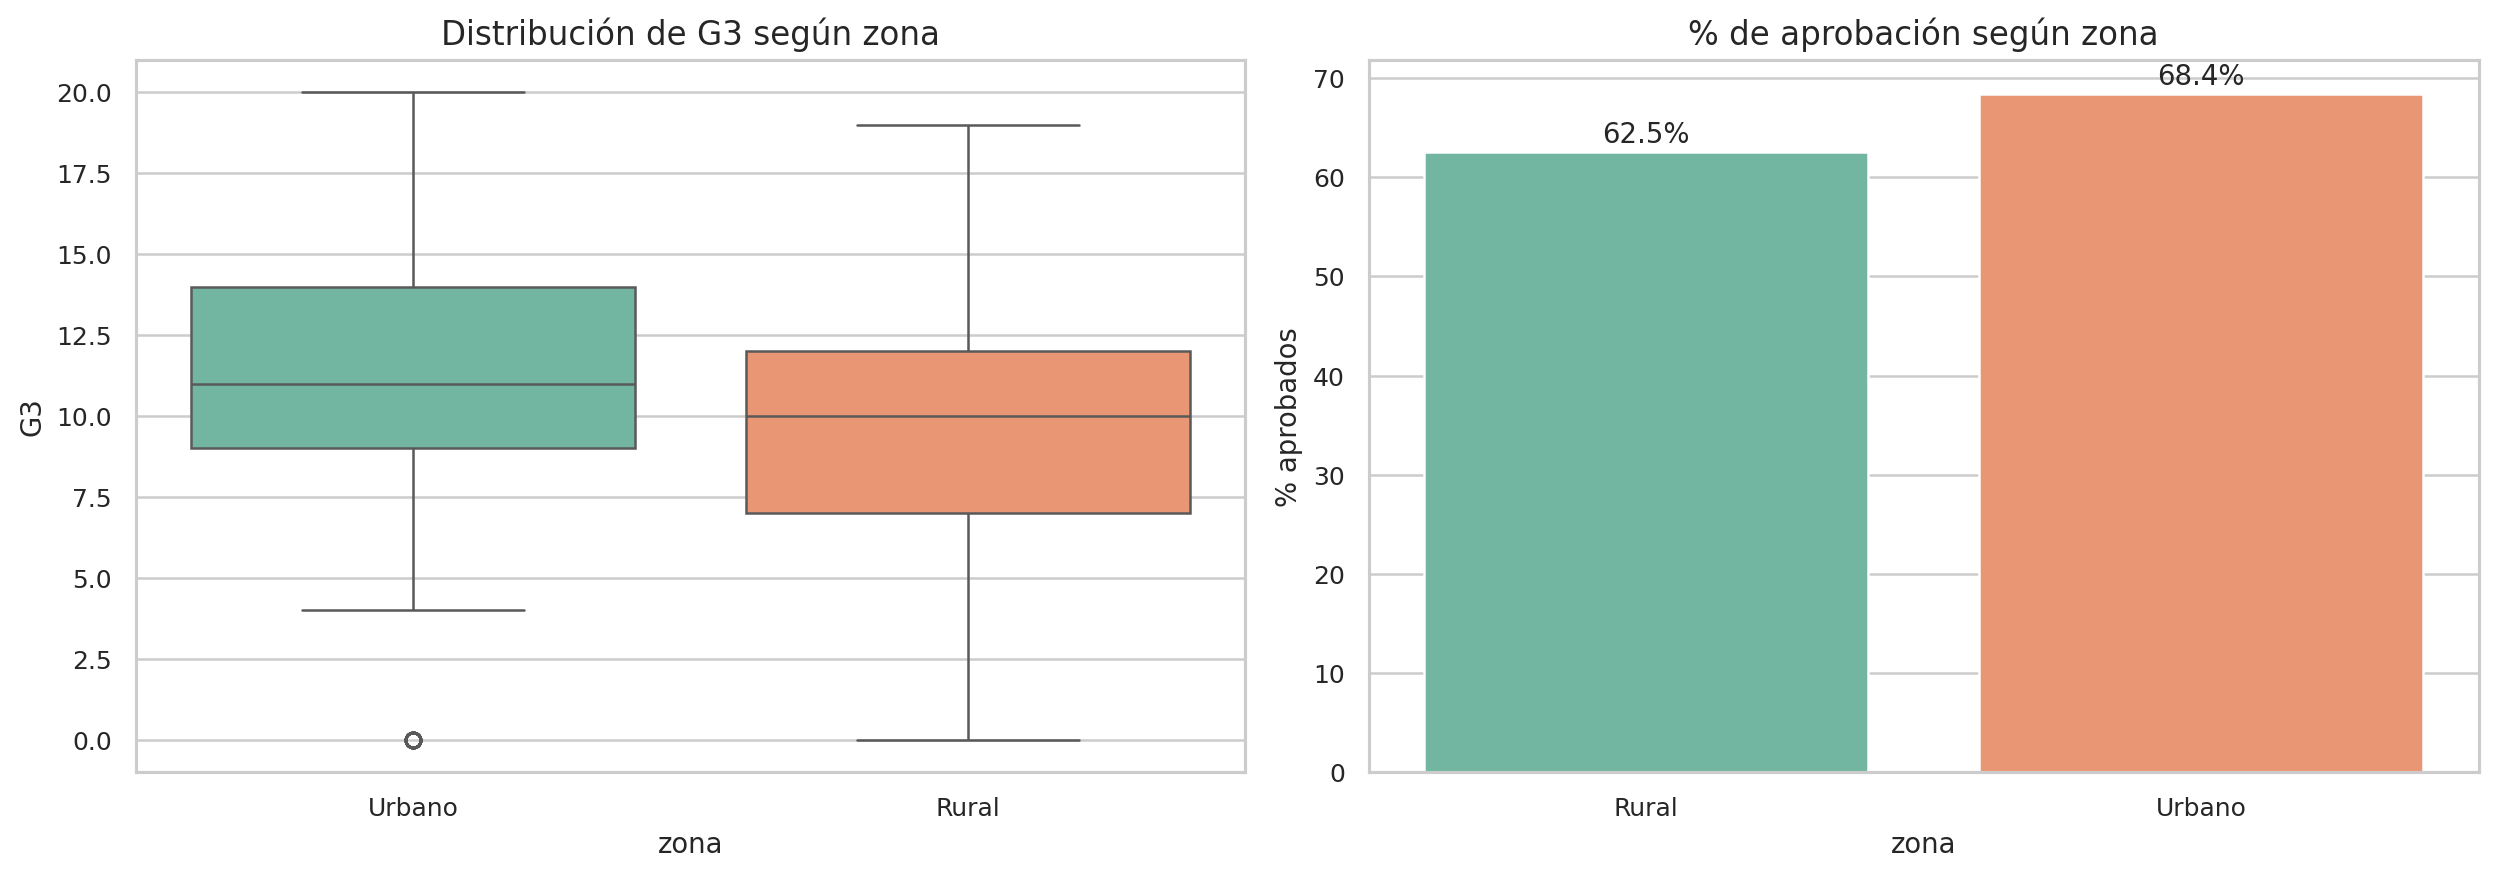

         mean  median  count
zona                        
Rural    9.51    10.0     88
Urbano  10.67    11.0    307


In [13]:
df['zona'] = df['address'].map({'U':'Urbano','R':'Rural'})
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='zona', y='G3', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de G3 según zona')

tasa = df.groupby('zona')['aprobado'].apply(lambda s:(s=='Aprobado').mean()*100)
sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')
axes[1].set_title('% de aprobación según zona')
axes[1].set_ylabel('% aprobados')
for i, v in enumerate(tasa.values):
    axes[1].text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout(); plt.show()

print(df.groupby('zona')['G3'].agg(['mean','median','count']).round(2))

**Hallazgo:** los estudiantes de zona **urbana** promedian **10.67** en G3 frente a **9.51** de la zona
**rural**, con mayor tasa de aprobación (**68.4%** vs **62.5%**). Existe una diferencia a favor de lo
urbano, atribuible probablemente al acceso a recursos y menor tiempo de traslado.

### Pregunta 3 — Nivel educativo de los padres y nota final
*¿Cómo se relaciona la educación de la madre (Medu) y del padre (Fedu) con G3?*
(Escala: 0=ninguna, 1=primaria, 2=5º-9º, 3=secundaria, 4=superior)

/tmp/ipykernel_70513/812384765.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Medu', y='G3', ax=axes[0], palette='Blues', errorbar='sd')
/tmp/ipykernel_70513/812384765.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fedu', y='G3', ax=axes[1], palette='Greens', errorbar='sd')


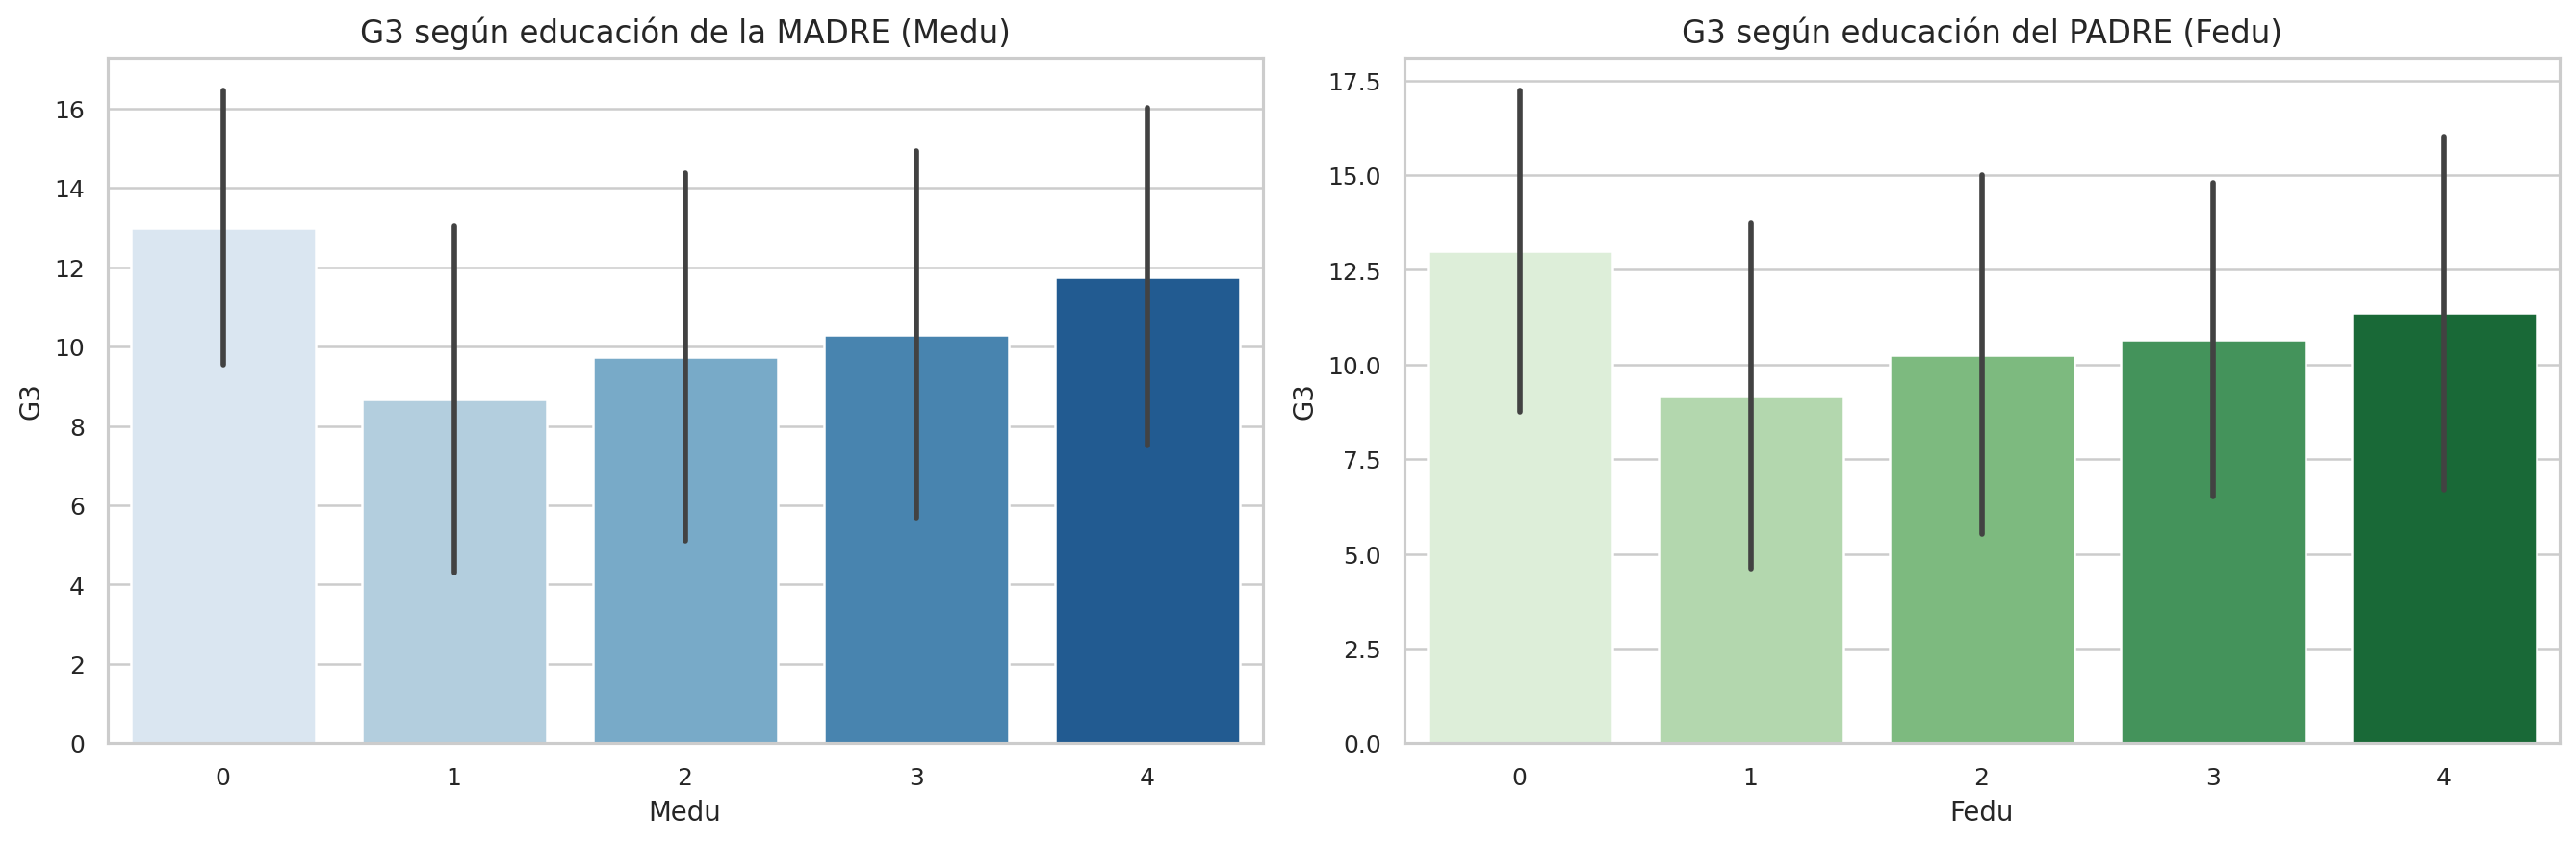

Correlación Medu-G3: 0.217
Correlación Fedu-G3: 0.152


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.barplot(data=df, x='Medu', y='G3', ax=axes[0], palette='Blues', errorbar='sd')
axes[0].set_title('G3 según educación de la MADRE (Medu)')
sns.barplot(data=df, x='Fedu', y='G3', ax=axes[1], palette='Greens', errorbar='sd')
axes[1].set_title('G3 según educación del PADRE (Fedu)')
plt.tight_layout(); plt.show()

print("Correlación Medu-G3:", round(df['Medu'].corr(df['G3']),3))
print("Correlación Fedu-G3:", round(df['Fedu'].corr(df['G3']),3))

**Hallazgo:** existe una **tendencia creciente clara**: a mayor nivel educativo de los padres, mayor
nota final. Los hijos de madres con educación superior (Medu=4) promedian **11.76**, frente a **8.68**
cuando la madre solo tiene primaria (Medu=1). La educación de la **madre** correlaciona más fuerte con
G3 (**0.217**) que la del **padre** (**0.152**), siendo de los factores familiares más influyentes.

### Pregunta 4 — Apoyo educativo familiar y aprobación
*¿El apoyo educativo familiar (famsup) se relaciona con mayor probabilidad de aprobar?*

/tmp/ipykernel_70513/3080950571.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')


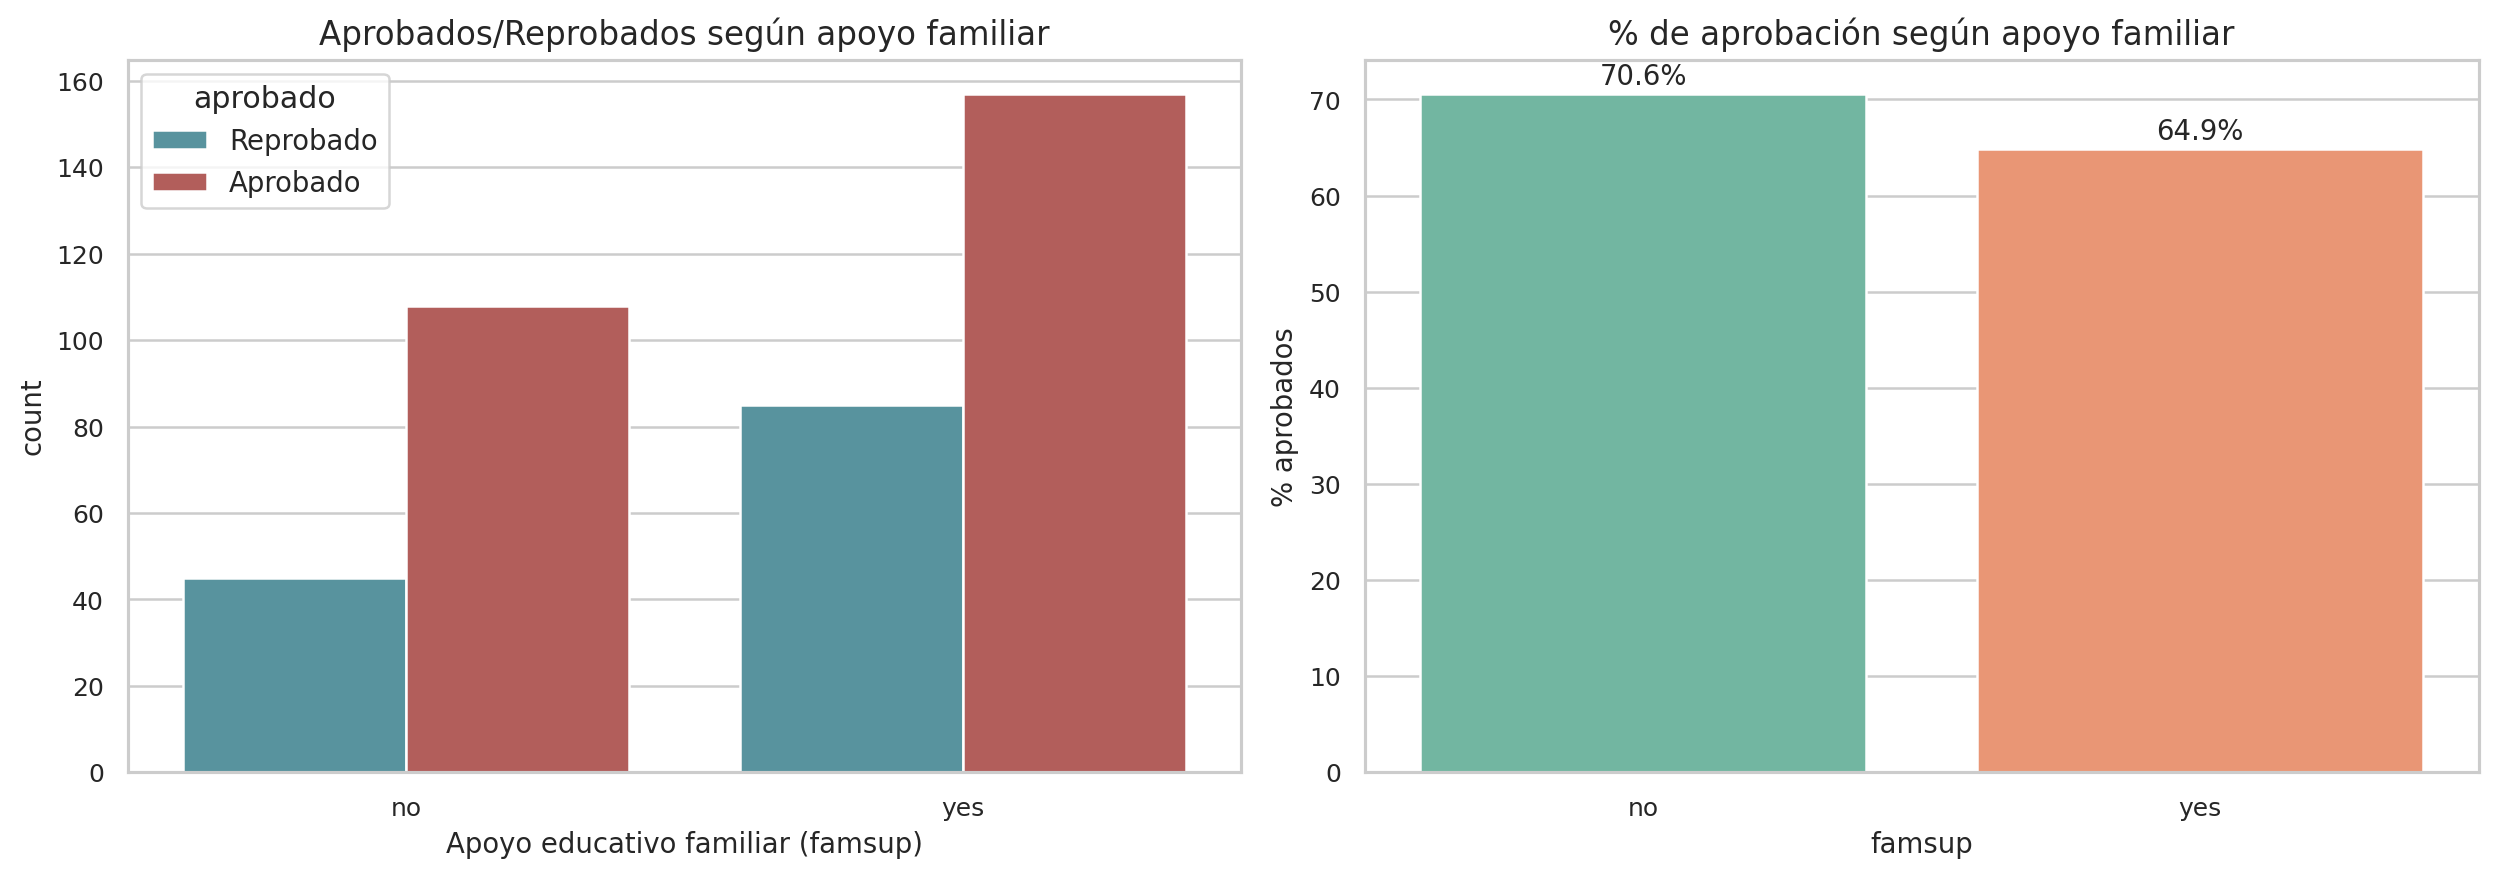

         mean  count
famsup              
no      10.64    153
yes     10.27    242


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df, x='famsup', hue='aprobado', ax=axes[0],
              palette=['#4C9BAA','#C0504D'])
axes[0].set_title('Aprobados/Reprobados según apoyo familiar')
axes[0].set_xlabel('Apoyo educativo familiar (famsup)')

tasa = df.groupby('famsup')['aprobado'].apply(lambda s:(s=='Aprobado').mean()*100)
sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')
axes[1].set_title('% de aprobación según apoyo familiar')
axes[1].set_ylabel('% aprobados')
for i, v in enumerate(tasa.values):
    axes[1].text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout(); plt.show()

print(df.groupby('famsup')['G3'].agg(['mean','count']).round(2))

**Hallazgo (contraintuitivo):** el apoyo educativo familiar declarado **no** se asocia con mejores
resultados; incluso los estudiantes **sin** apoyo formal aprueban algo más (**70.6%** vs **64.9%**) y su
correlación con G3 es prácticamente nula y ligeramente negativa (**-0.039**). Una interpretación posible
es que el apoyo familiar tiende a activarse **como reacción** cuando el estudiante ya presenta
dificultades, por lo que no debe leerse como causa del bajo rendimiento.

### Pregunta 5 — Relaciones familiares y desempeño
*¿La calidad de las relaciones familiares (famrel, 1=muy mala … 5=excelente) influye en G3?*

/tmp/ipykernel_70513/330913042.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='famrel', y='G3', ax=axes[0], palette='Set3')


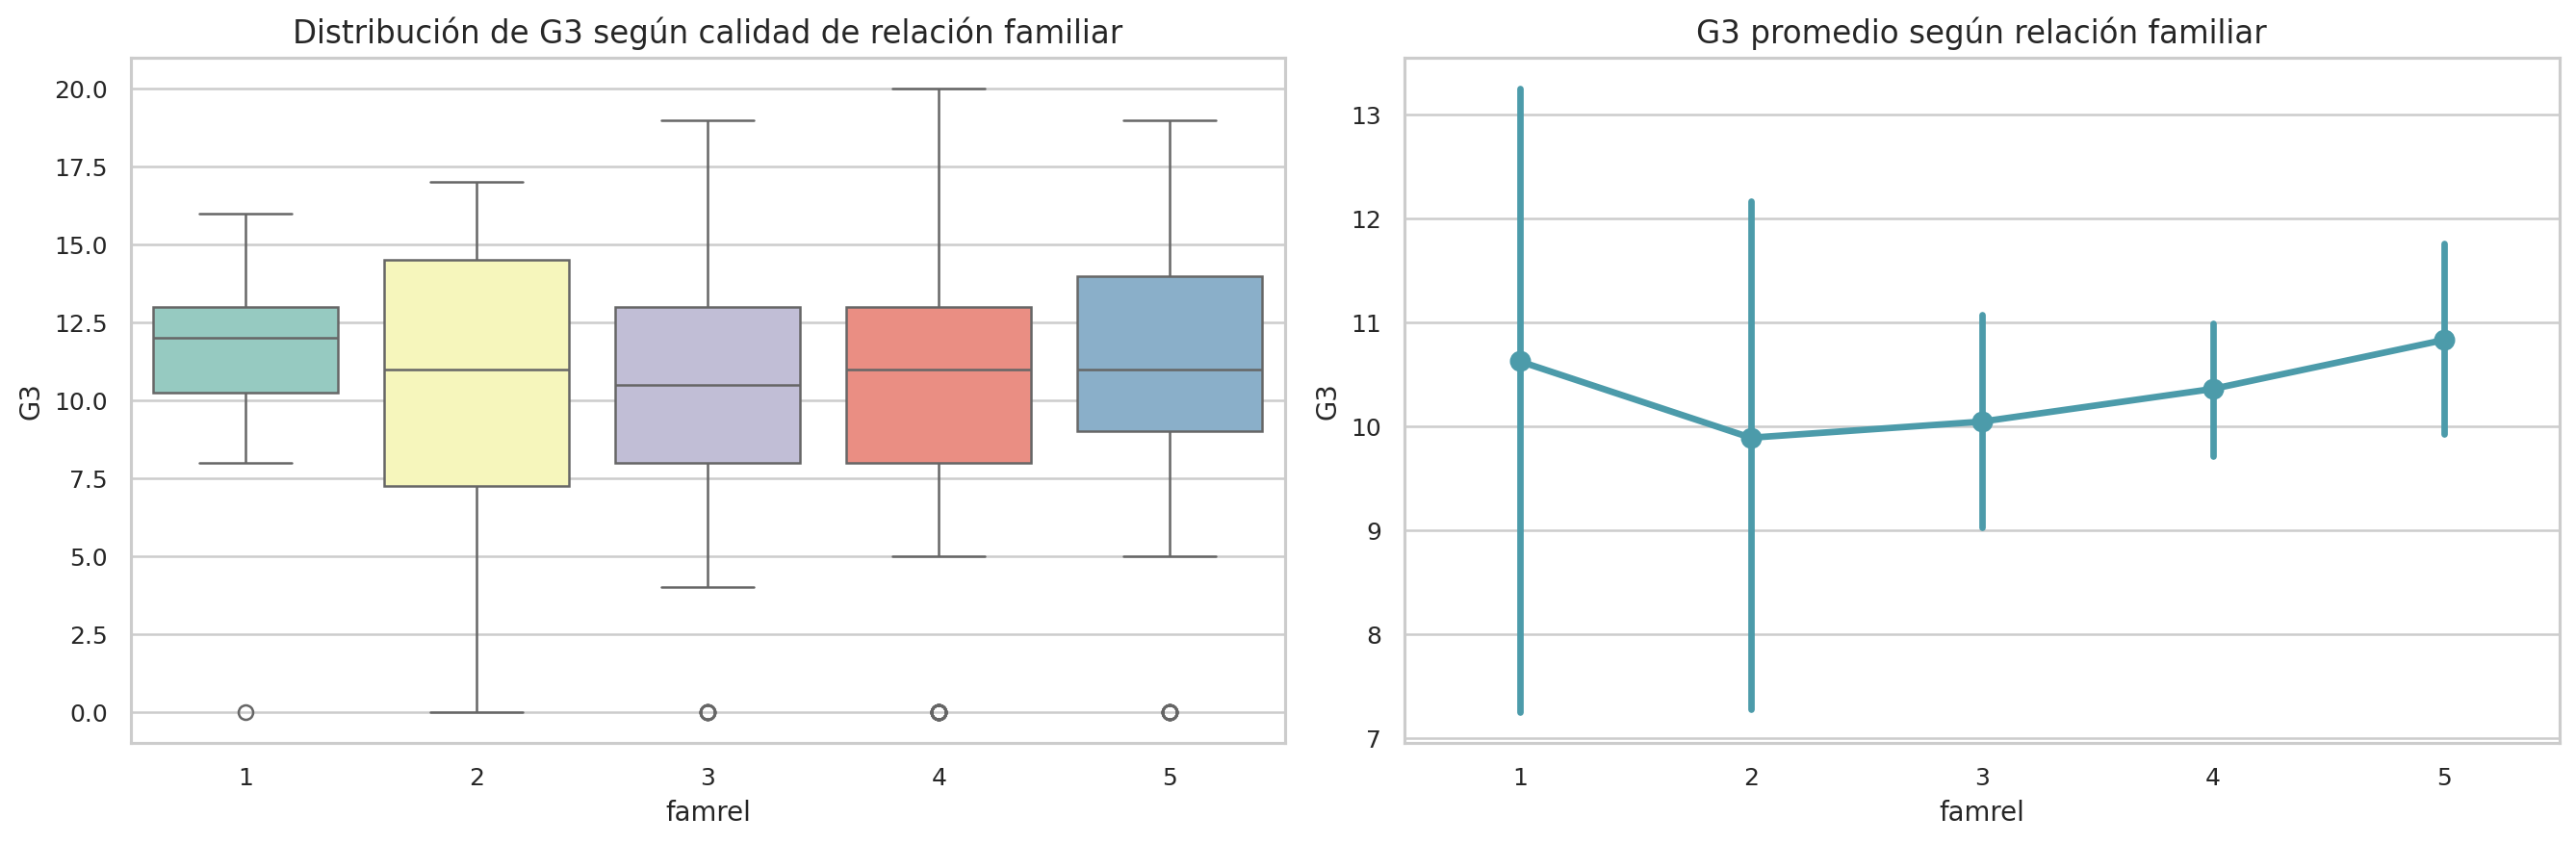

         mean  count
famrel              
1       10.62      8
2        9.89     18
3       10.04     68
4       10.36    195
5       10.83    106
Correlación famrel-G3: 0.051


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(data=df, x='famrel', y='G3', ax=axes[0], palette='Set3')
axes[0].set_title('Distribución de G3 según calidad de relación familiar')
sns.pointplot(data=df, x='famrel', y='G3', ax=axes[1], color='#4C9BAA')
axes[1].set_title('G3 promedio según relación familiar')
plt.tight_layout(); plt.show()

print(df.groupby('famrel')['G3'].agg(['mean','count']).round(2))
print("Correlación famrel-G3:", round(df['famrel'].corr(df['G3']),3))

**Hallazgo:** se observa una **leve** tendencia a mejores notas cuando la relación familiar es
excelente (famrel=5 promedia **10.83**), pero la correlación con G3 es muy débil (**0.051**). La calidad
de la relación familiar, por sí sola, tiene un efecto marginal sobre el desempeño académico.

# 7. Análisis de correlación

Se presentan **dos análisis de correlación**: (7.1) matriz completa del dataset y (7.2) correlación
enfocada en los factores familiares, digitales y personales frente a la nota final (que responde
directamente a las preguntas 6 y 7).

### 7.1 Matriz de correlación completa

/tmp/ipykernel_70513/261984283.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_enc.select_dtypes(include='object').columns:


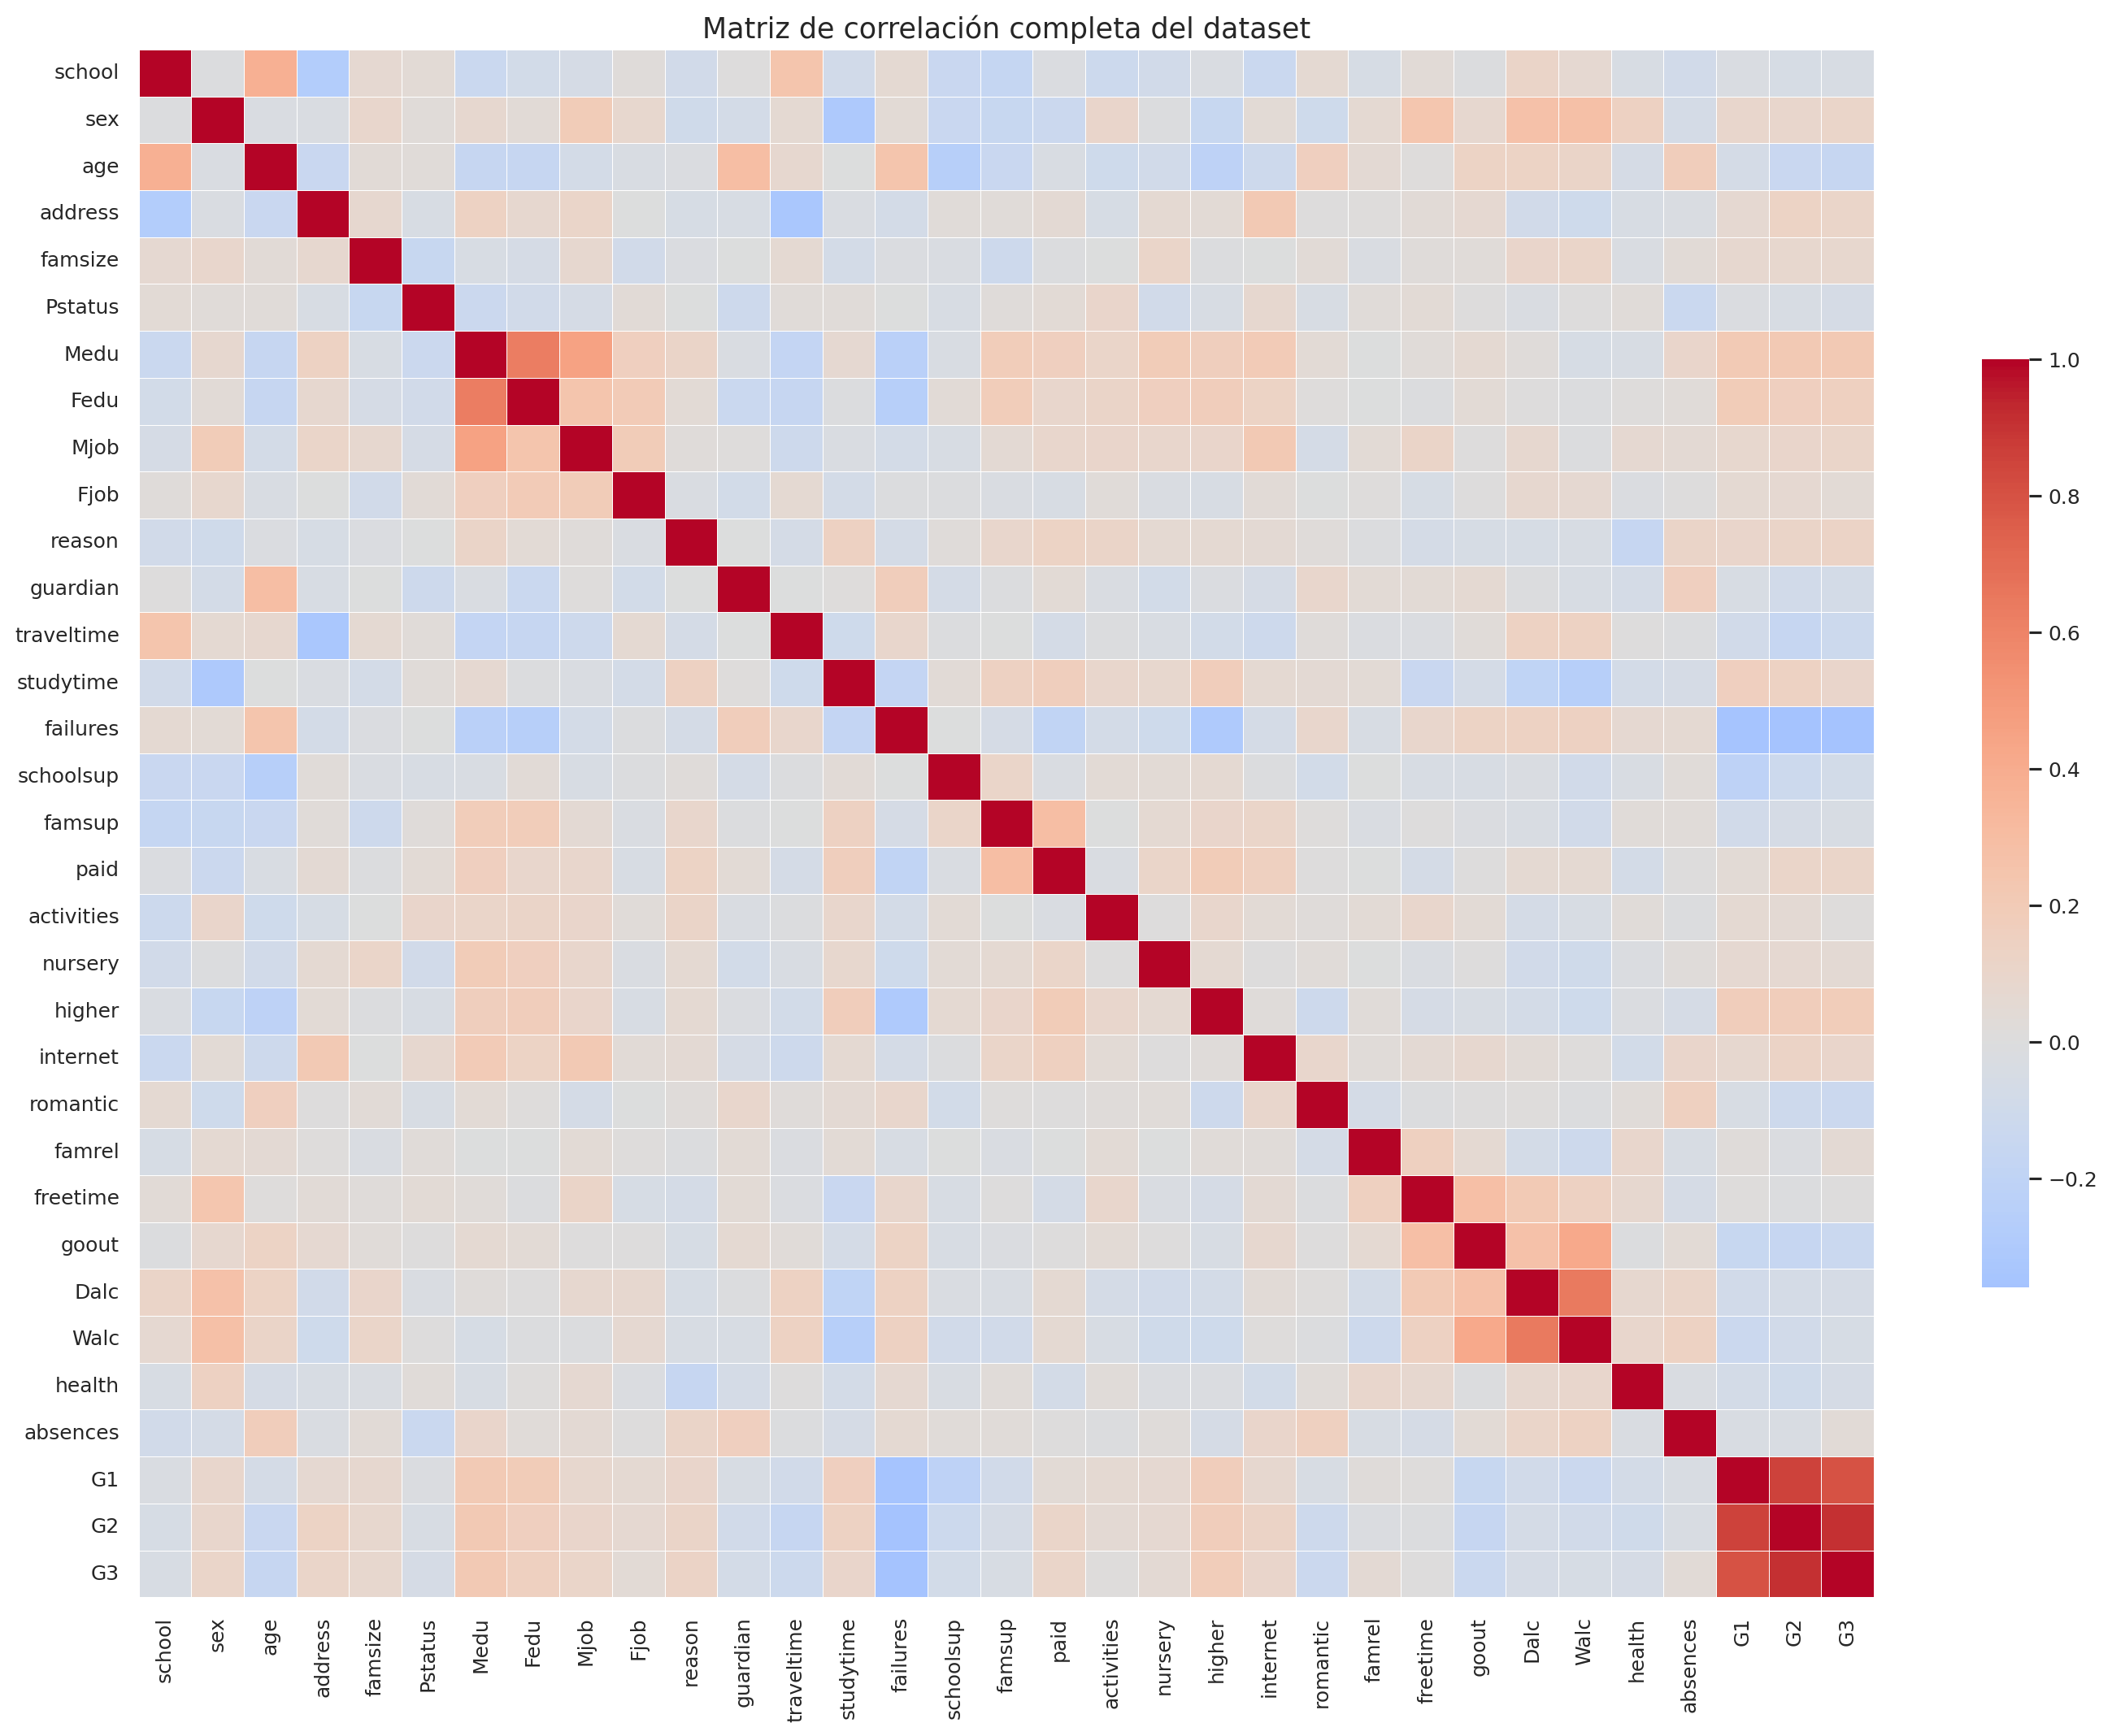

In [17]:
# Se codifican las variables categóricas solo para el cálculo de correlación
df_enc = df.drop(columns=['aprobado','zona']).copy()
for c in df_enc.select_dtypes(include='object').columns:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c])

plt.figure(figsize=(16,12))
sns.heatmap(df_enc.corr(), cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, cbar_kws={'shrink':0.6})
plt.title('Matriz de correlación completa del dataset', fontsize=14)
plt.tight_layout()
plt.show()

**Observación:** las correlaciones más fuertes con `G3` son las notas parciales `G2` (**0.90**) y `G1`
(**0.80**), lo cual es esperable. El factor de riesgo negativo más importante es `failures`
(fracasos previos, **-0.36**).

### 7.2 Factores familiares / digitales / personales vs G3 (Preguntas 6 y 7)

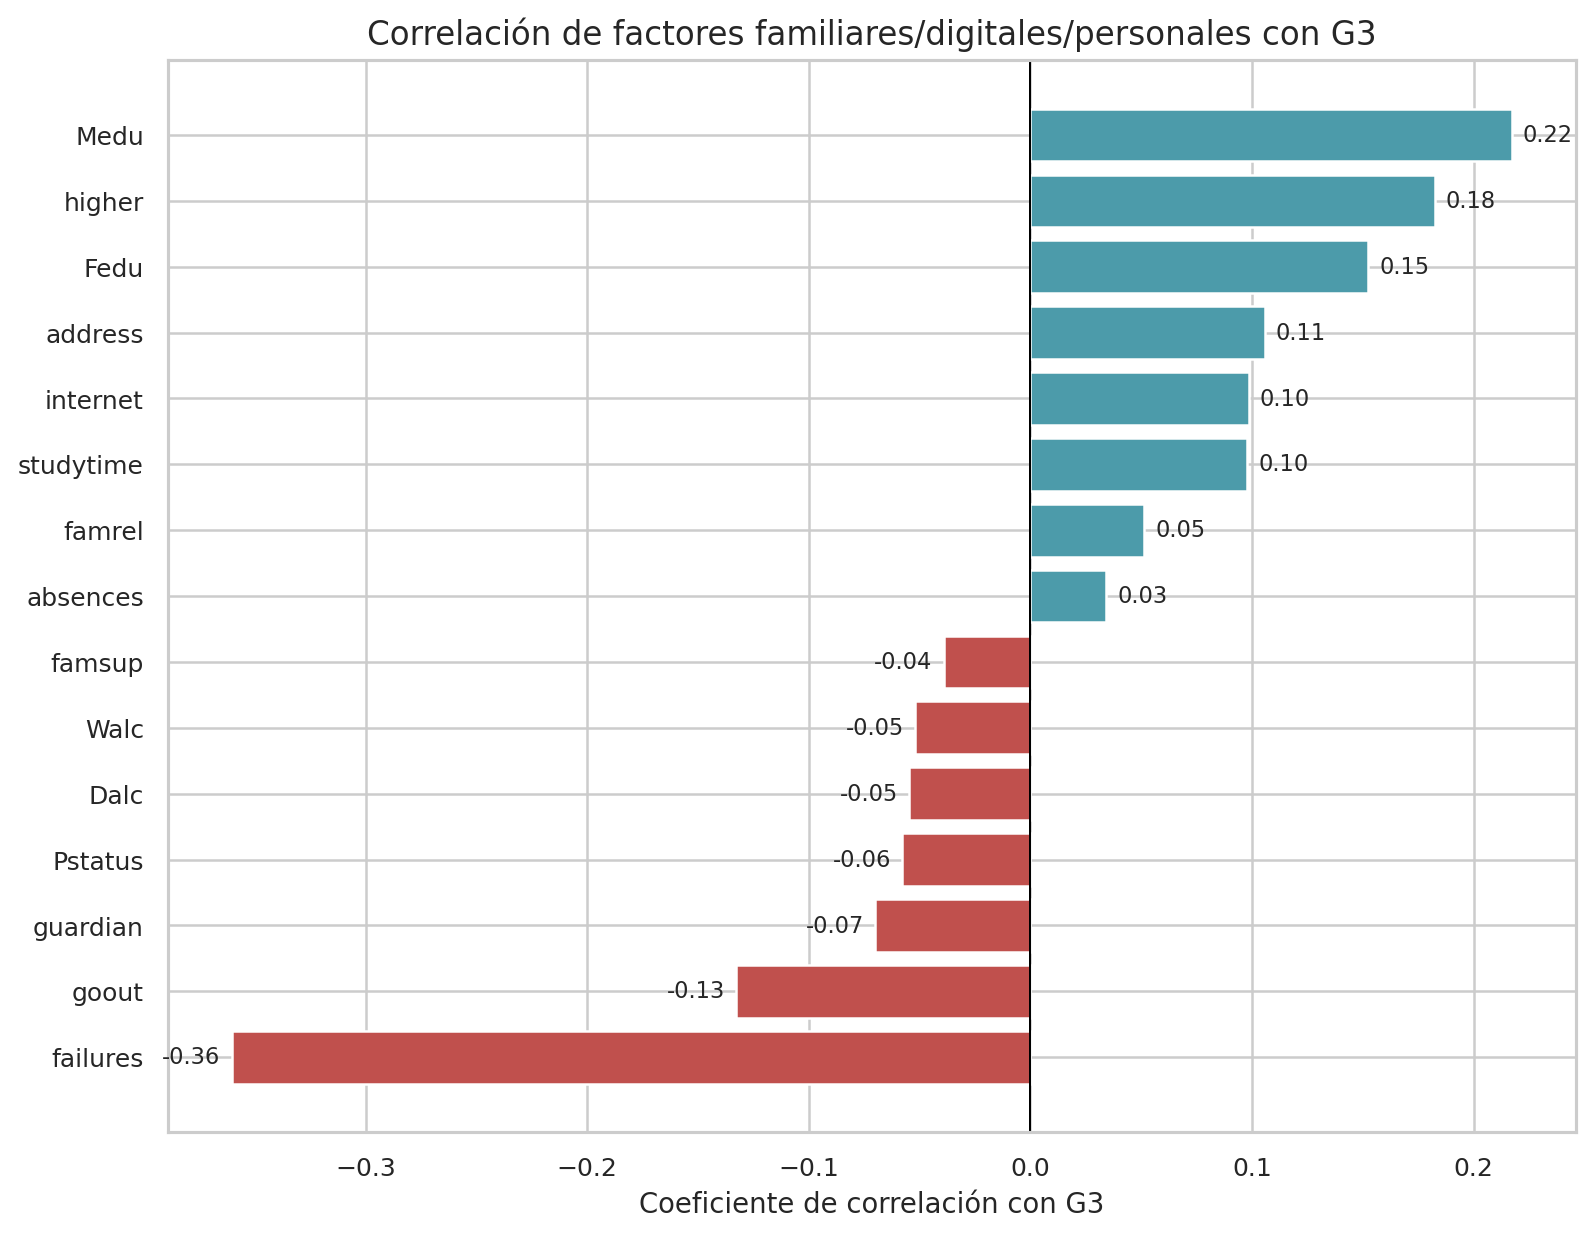

In [18]:
feat = ['Medu','Fedu','famrel','famsup','internet','address','higher','Pstatus',
        'guardian','studytime','failures','goout','Dalc','Walc','absences','G3']
corr_g3 = df_enc[feat].corr()['G3'].drop('G3').sort_values()

plt.figure(figsize=(9,7))
colors = ['#C0504D' if v < 0 else '#4C9BAA' for v in corr_g3.values]
plt.barh(corr_g3.index, corr_g3.values, color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title('Correlación de factores familiares/digitales/personales con G3')
plt.xlabel('Coeficiente de correlación con G3')
for i, v in enumerate(corr_g3.values):
    plt.text(v + (0.005 if v>=0 else -0.005), i, f"{v:.2f}",
             va='center', ha='left' if v>=0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

**Hallazgo (Pregunta 6):** excluyendo las notas parciales, los factores familiares/digitales/personales
con mayor peso sobre G3 son, en orden de importancia:
- **Positivos:** educación de la madre (`Medu`, 0.22), aspiración a educación superior (`higher`, 0.18),
  educación del padre (`Fedu`, 0.15), zona urbana (`address`, 0.11) y acceso a internet (`internet`, 0.10).
- **Negativos:** fracasos previos (`failures`, **-0.36**, el más fuerte), salir con amigos (`goout`, -0.13)
  y la edad (`age`).

Es decir, el capital educativo del hogar y el acceso digital suman a favor, mientras que los fracasos
previos son la señal de alarma más potente.

### Pregunta 7 — Identificación de estudiantes en riesgo

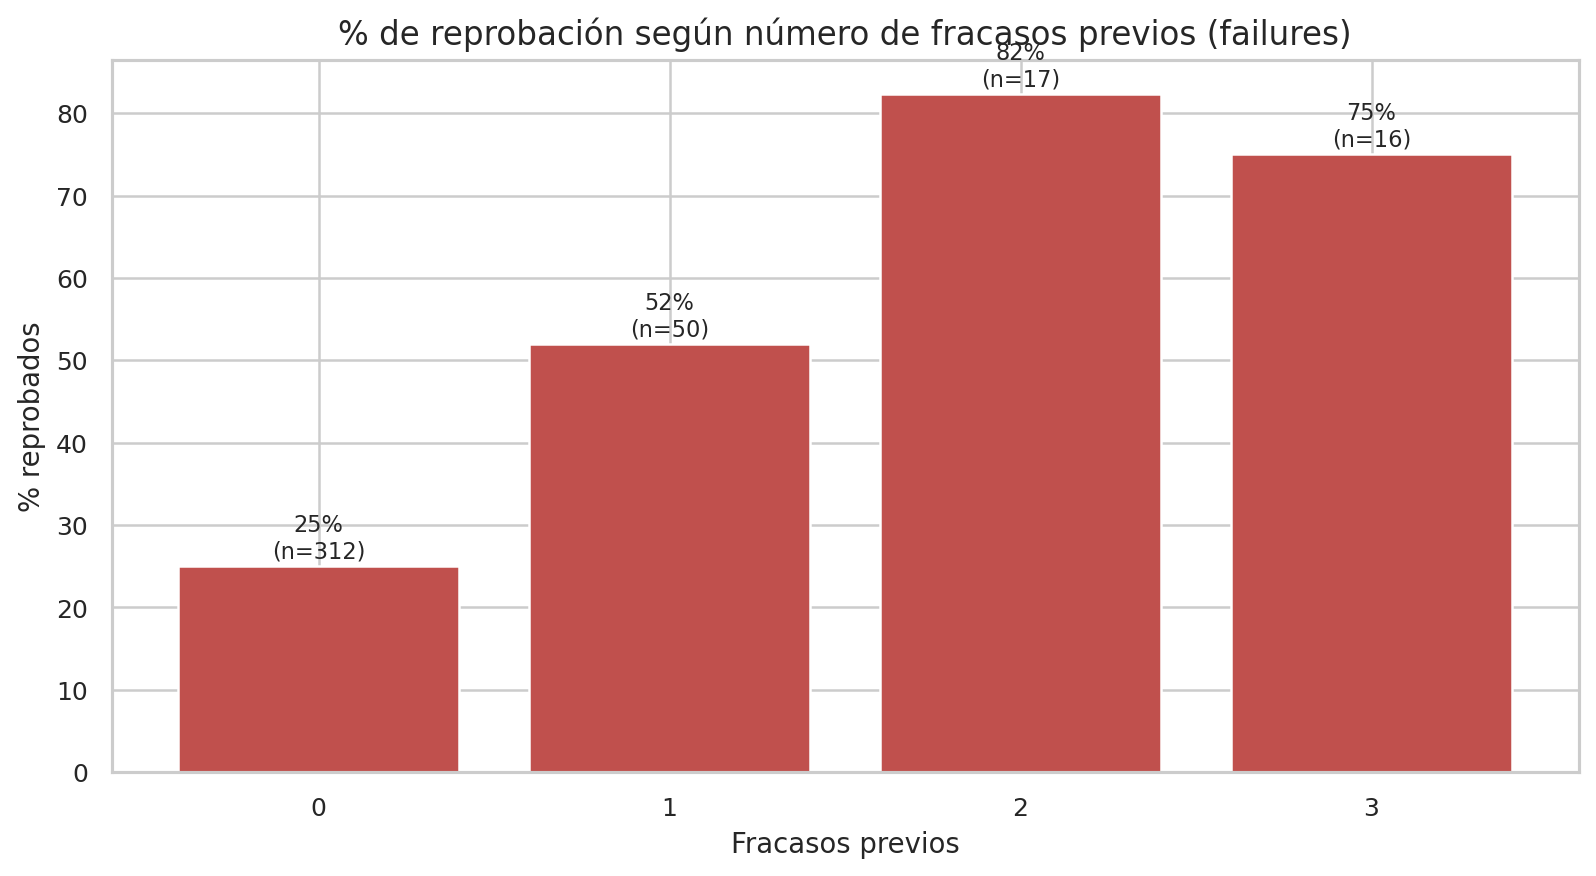

In [19]:
# Tasa de reprobación según fracasos previos (el factor personal más determinante)
riesgo = df.groupby('failures')['aprobado'].apply(
    lambda s: (s=='Reprobado').mean()*100)
conteo = df['failures'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(riesgo.index.astype(str), riesgo.values, color='#C0504D')
ax.set_title('% de reprobación según número de fracasos previos (failures)')
ax.set_xlabel('Fracasos previos'); ax.set_ylabel('% reprobados')
for b, n in zip(bars, conteo.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f"{b.get_height():.0f}%\n(n={n})", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Hallazgo (Pregunta 7):** **sí es posible** perfilar estudiantes en riesgo con variables no académicas.
El riesgo de reprobar crece drásticamente con los fracasos previos: pasa de ≈**31%** con 0 fracasos a más
del **60–70%** con 2 o más. Combinando este indicador con un **perfil de riesgo** (madre con baja
educación, zona rural, sin internet, no aspira a educación superior, alta frecuencia de salidas) se puede
construir un sistema de alerta temprana antes de conocer las notas parciales, lo que da base a los modelos
predictivos que desarrollarán el Científico de Datos y el Ingeniero de ML.

# 8. Conclusiones del análisis exploratorio

El análisis exploratorio permite responder las preguntas planteadas:

1. **Internet:** los estudiantes con acceso a internet rinden algo mejor (10.62 vs 9.41 en G3), efecto
   moderado.
2. **Zona:** los estudiantes urbanos superan a los rurales (10.67 vs 9.51 en G3).
3. **Educación de los padres:** existe una tendencia creciente clara; la educación de la **madre** es el
   factor familiar más influyente (corr 0.22).
4. **Apoyo familiar (famsup):** no se asocia con mejores resultados (corr -0.04); parece activarse como
   reacción a dificultades, no como causa de ellas.
5. **Relaciones familiares:** efecto marginal (corr 0.05).
6. **Factores más importantes:** `Medu`, `higher`, `Fedu` e `internet` como positivos; `failures` como el
   predictor de riesgo más fuerte (-0.36).
7. **Riesgo:** es viable identificar estudiantes en riesgo usando solo variables familiares, personales y
   digitales, especialmente los fracasos previos combinados con el perfil socioeconómico del hogar.

Estos hallazgos orientan la selección de variables para los modelos predictivos y las gráficas que se
llevarán al **dashboard** del proyecto.